# 04. Multi-Class Modeling

**Goal:** Train and compare Logistic Regression and Naive Bayes on the 5-class dataset.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import joblib
import sys
sys.path.append('../../../shared')
from evaluation_utils import evaluate_classification

## 1. Load Vectorized Data

In [2]:
X_train, X_test, y_train, y_test, vectorizer = joblib.load('../data/processed/tfidf_bbc.pkl')
labels = sorted(y_train.unique())

> **📌 Decision Note — Why Multi-Class Strategy?**
>
> **Chosen approach:** MultinomialNB and LogisticRegression (multinomial/OVR)
>
> **Why this works:** Both handle multi-class problems natively or via One-Vs-Rest seamlessly.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Binary Classifiers | Good for 1v1 | Complex to orchestrate for 5 classes manually. |
> | Tree-based (Random Forest) | Handles non-linear | Usually underperforms on high-dimensional sparse text compared to linear models. |
>
> **Why we chose this over alternatives:** Linear models and Naive Bayes are the golden standard for BoW/TF-IDF text classification.

## 2. Multinomial Naive Bayes

Accuracy: 0.950561797752809

Classification Report:

               precision    recall  f1-score   support

     business       0.96      0.94      0.95       115
entertainment       0.97      0.89      0.93        72
     politics       0.86      0.97      0.91        76
        sport       0.98      1.00      0.99       102
         tech       0.97      0.94      0.96        80

     accuracy                           0.95       445
    macro avg       0.95      0.95      0.95       445
 weighted avg       0.95      0.95      0.95       445



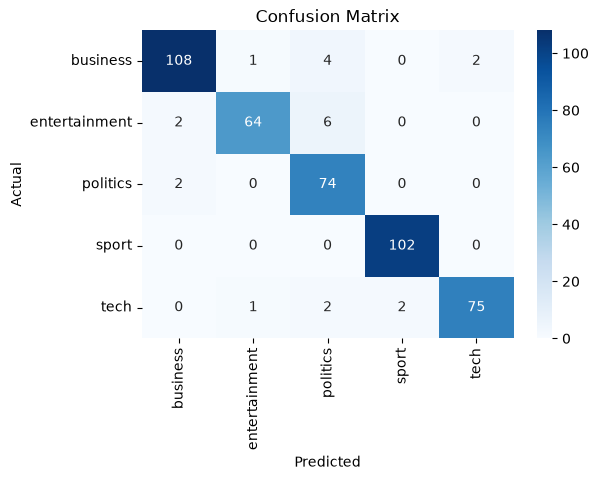

In [3]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
evaluate_classification(y_test, y_pred_nb, labels=labels)

## 3. Logistic Regression

Accuracy: 0.9617977528089887

Classification Report:

               precision    recall  f1-score   support

     business       0.96      0.96      0.96       115
entertainment       0.97      0.92      0.94        72
     politics       0.91      0.99      0.95        76
        sport       0.97      1.00      0.99       102
         tech       0.99      0.94      0.96        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445



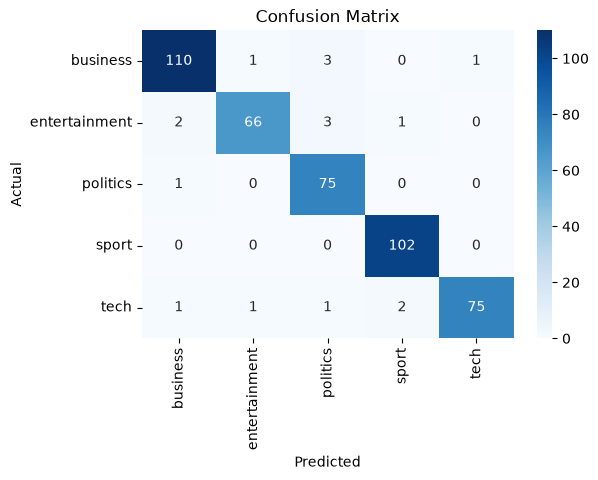

In [4]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_classification(y_test, y_pred_lr, labels=labels)

## Key Takeaways
- [x] Both models should achieve >95% accuracy.
- [x] Look at the confusion matrix to see which categories get confused the most (e.g., Tech vs Business).